In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

In [1]:
import cv2
print(hasattr(cv2, "ximgproc"))
print(hasattr(cv2.ximgproc, "guidedFilter"))

True
True


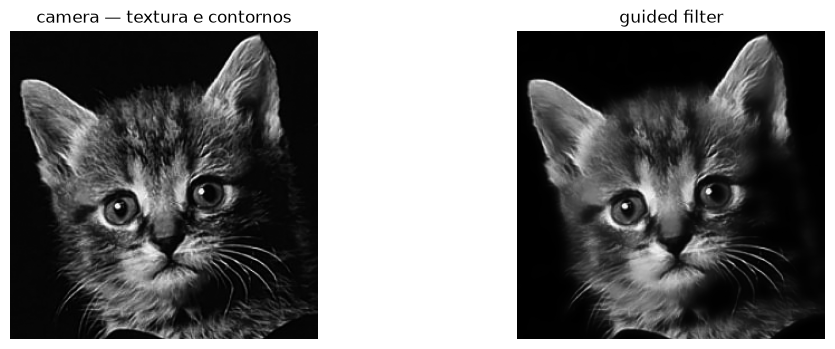

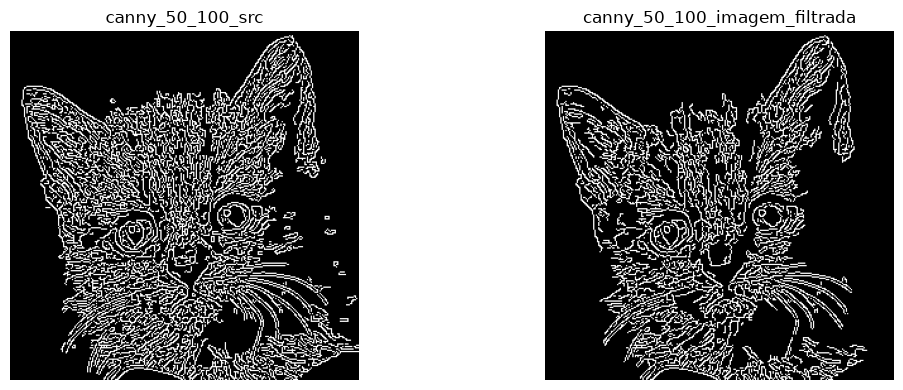

In [ ]:
QUANTIDADE_IMAGENS = 1  # Define a quantidade de imagens a serem processadas.

lista_imagens = []
lista_imagens_filtradas = []


# Parâmetros: raio do filtro (radius) e regularização (eps)
radius = 4
eps = 0.01  # Exemplo de escala para imagens de 8 bits


for i in range(1, QUANTIDADE_IMAGENS+1):

    caminho_entrada = f"images/imagem{i:02d}.pgm"
    caminho_saida = f"images_pgm_py_filtradas/resultado{i:02d}.pgm"


    src = cv2.imread(caminho_entrada, cv2.IMREAD_GRAYSCALE)

    lista_imagens.append(src)

    src = src.astype(np.float32) / 255.0

    # Aplicação direta do Guided Filter
    output_expected = cv2.ximgproc.guidedFilter(guide=src, src=src, radius=radius, eps=eps) # aplicação do filtro em float

    output_expected = (output_expected * 255).astype(np.uint8) # cast da saida de float para usigned char

    cv2.imwrite(caminho_saida, output_expected)

    lista_imagens_filtradas.append(output_expected)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Cria três painéis para apresentar as imagens de referência.
axes[0].imshow(lista_imagens[0], cmap="gray", vmin=0, vmax=255)  # Exibe a imagem camera em tons de cinza.
axes[0].set_title("camera — textura e contornos")  # Explica a característica principal da primeira imagem.
axes[0].axis('off')

axes[1].imshow(lista_imagens_filtradas[0], cmap="gray")  # Exibe a imagem em tons de cinza.
axes[1].set_title("guided filter")  # Explica a característica principal da segunda imagem.
axes[1].axis('off')

canny_50_100 = cv2.Canny(lista_imagens[0], 50, 100)  # Executa Canny com limiares mais baixos.
canny_50_100_2 = cv2.Canny(lista_imagens_filtradas[0], 50, 100)  # Executa Canny com limiares mais baixos.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Cria quatro painéis para comparar a influência dos limiares.
axes[0].imshow(canny_50_100, cmap="gray", vmin=0, vmax=255)  # Exibe a imagem camera em tons de cinza.
axes[0].set_title("canny_50_100_src")  # Explica a característica principal da primeira imagem.
axes[0].axis('off')
axes[1].imshow(canny_50_100_2, cmap="gray", vmin=0, vmax=255)  # Exibe a imagem em tons de cinza.
axes[1].set_title("canny_50_100_imagem_filtrada")  # Explica a característica principal da segunda imagem.
axes[1].axis('off')


plt.tight_layout()  # Ajusta os espaçamentos.
plt.show()  # Renderiza a comparação.


Diferentes: 935 pixels (1.2274% do total)
Maior diferença: 4
Primeiros pixels diferentes (linha, coluna):
[[  0  29]
 [  0  42]
 [  0  43]
 [  0  44]
 [  0  50]
 [  0 114]
 [  0 139]
 [  0 140]
 [  0 141]
 [  0 142]]


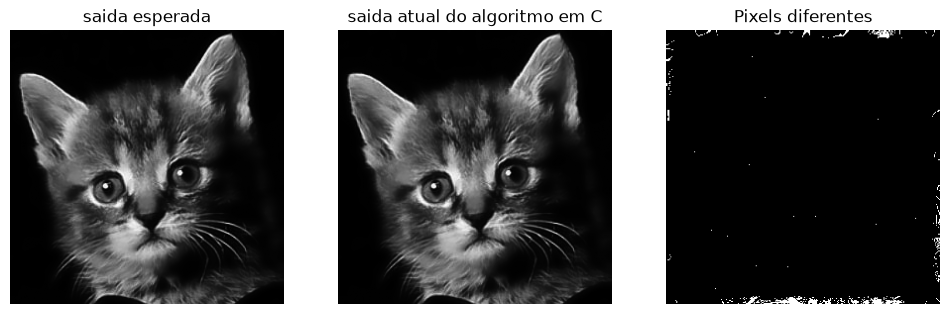

In [9]:

# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)
output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

output_expected = cv2.imread("images_pgm_py_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

if output_expected.shape != output_actual.shape:
    print("Diferentes: dimensões distintas")
elif output_expected.dtype != output_actual.dtype:
    print("Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
elif np.array_equal(output_expected, output_actual):
    print("As imagens são idênticas pixel a pixel")
else:
    mask = output_expected != output_actual
    n_diff = mask.sum()
    print(f"Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

    # diferença absoluta em tipo maior, para evitar overflow do uint8
    diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
    print("Maior diferença:", diff.max())

    coords = np.argwhere(mask)
    print("Primeiros pixels diferentes (linha, coluna):")
    print(coords[:10])


fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(output_expected, cmap="gray"); axs[0].set_title("saida esperada")
axs[1].imshow(output_actual, cmap="gray"); axs[1].set_title("saida atual do algoritmo em C")
axs[2].imshow(mask, cmap="gray"); axs[2].set_title("Pixels diferentes")
for ax in axs:
    ax.axis("off")
plt.show()